In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import Image, HTML
from sklearn.model_selection import train_test_split
import xgboost as xgb
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import KFold, cross_val_score


In [102]:
ev2 =  pd.read_csv('../../Datasets/evaluacion2.csv')
ev2.head(3)

,product_title,product_rating,is_best_seller,is_sponsored,buy_box_availability,sustainability_tags,has_coupon,discount_percentage,product_category,product_segment,log_original_price,log_purchased_last_month,log_total_reviews
0,OWC 2.0TB Aura Pro X2 (GEN 4) SSD Complete Upg...,4.4,No Badge,Sponsored,1,0,0,0.0,PC Components,Media,5.484755,0.000000,5.883322
1,OWC 250GB Aura Pro 6G Flash SSD Upgrade for 20...,4.6,No Badge,Sponsored,1,0,0,0.0,Storage & Memory Cards,Media,3.783962,0.000000,5.624018
2,HP 67XL Black High-yield Ink Cartridge | Works...,4.6,Best Seller,Organic,0,1,0,0.0,"Office Supplies, Ink & Toner",Media,3.607941,10.819798,11.523598


In [15]:
def info_df(df):
    return pd.DataFrame({
    'Columna': df.columns,
    'No Nulos': df.notnull().sum().values,
    'Nulos': df.isnull().sum().values,
    'Tipo Python': df.dtypes.values,
    'Núm. valores': [len(df[col].unique()) for col in df.columns]
     })
info = info_df(ev2)
info

,Columna,No Nulos,Nulos,Tipo Python,Núm. valores
0,product_rating,7717,0,float64,31
1,is_best_seller,7717,0,object,11
2,is_sponsored,7717,0,object,2
3,buy_box_availability,7717,0,int64,2
4,sustainability_tags,7717,0,int64,2
5,has_coupon,7717,0,int64,2
6,discount_percentage,7717,0,float64,72
7,product_category,7717,0,object,19
8,product_segment,7717,0,object,3
9,log_original_price,7717,0,float64,3061


In [46]:
ev2.drop(columns=['product_title'], inplace=True)

In [103]:
target = 'log_original_price'

In [104]:
X = ev2.drop(columns=[target])
y = ev2[target]
y_euro = np.expm1(y)

In [7]:
y_euro.head(3)

0    239.99
1     42.99
2     35.89
Name: log_original_price, dtype: float64

In [52]:
np.expm1(0.5)

0.6487212707001282

In [105]:
# Extract text features
cats = X.select_dtypes(exclude=np.number).columns.tolist()

# Convert to Pandas category
for col in cats:
   X[col] = X[col].astype('category')

In [106]:
X.dtypes

product_title               category
product_rating               float64
is_best_seller              category
is_sponsored                category
buy_box_availability           int64
sustainability_tags            int64
has_coupon                     int64
discount_percentage          float64
product_category            category
product_segment             category
log_purchased_last_month     float64
log_total_reviews            float64
dtype: object

In [107]:
X.shape, y.shape

((7717, 12), (7717,))

In [108]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Dimensiones de X_train: {X_train.shape}")
print(f"Dimensiones de X_test:  {X_test.shape}")

Dimensiones de X_train: (6173, 12)
Dimensiones de X_test:  (1544, 12)


C:\Users\USER\AppData\Local\Temp\ipykernel_31404\1541016602.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0, 1].boxplot([y_train, y_test], labels=['Train', 'Test'])


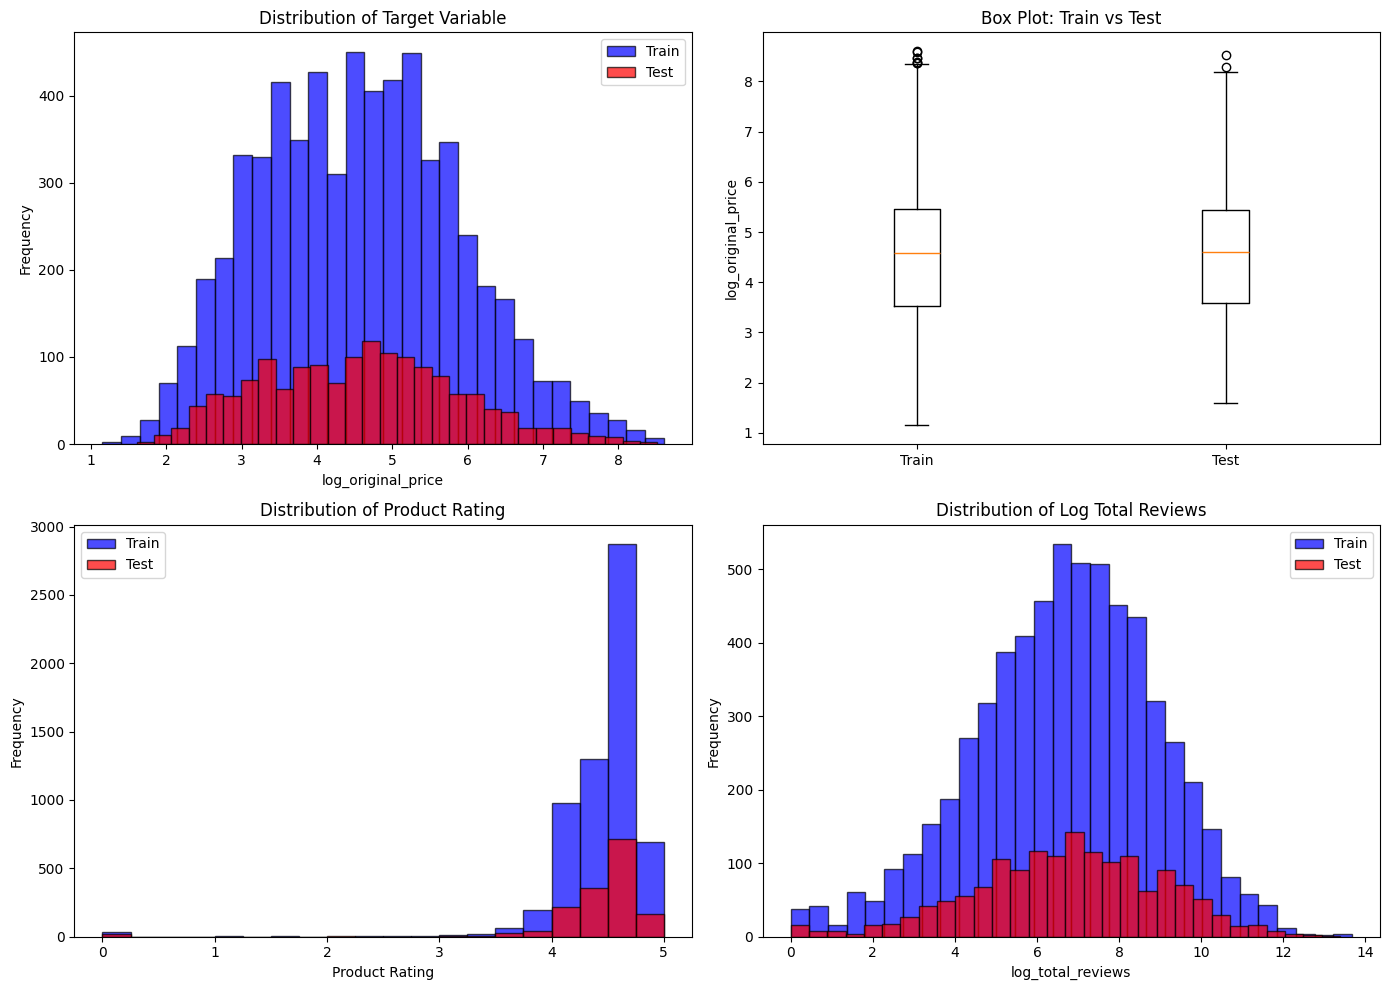

In [109]:
# Create visualizations for train and test data
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Distribution of target variable
axes[0, 0].hist(y_train, bins=30, alpha=0.7, label='Train', color='blue', edgecolor='black')
axes[0, 0].hist(y_test, bins=30, alpha=0.7, label='Test', color='red', edgecolor='black')
axes[0, 0].set_xlabel('log_original_price')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('Distribution of Target Variable')
axes[0, 0].legend()

# 2. Box plot comparison
axes[0, 1].boxplot([y_train, y_test], labels=['Train', 'Test'])
axes[0, 1].set_ylabel('log_original_price')
axes[0, 1].set_title('Box Plot: Train vs Test')

# 3. Product rating distribution
axes[1, 0].hist(X_train['product_rating'], bins=20, alpha=0.7, label='Train', color='blue', edgecolor='black')
axes[1, 0].hist(X_test['product_rating'], bins=20, alpha=0.7, label='Test', color='red', edgecolor='black')
axes[1, 0].set_xlabel('Product Rating')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].set_title('Distribution of Product Rating')
axes[1, 0].legend()

# 4. Log total reviews distribution
axes[1, 1].hist(X_train['log_total_reviews'], bins=30, alpha=0.7, label='Train', color='blue', edgecolor='black')
axes[1, 1].hist(X_test['log_total_reviews'], bins=30, alpha=0.7, label='Test', color='red', edgecolor='black')
axes[1, 1].set_xlabel('log_total_reviews')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].set_title('Distribution of Log Total Reviews')
axes[1, 1].legend()

plt.tight_layout()
plt.show()

In [54]:
dtrain_reg = xgb.DMatrix(X_train, y_train, enable_categorical=True)
dtest_reg = xgb.DMatrix(X_test, y_test, enable_categorical=True)

## VALIDACIÓN CRUZADA

In [94]:
params = {"objective": "reg:squarederror"}
n = 1000
results = xgb.cv(
   params, dtrain_reg,
   num_boost_round=n,
   nfold=5,
   early_stopping_rounds=20
)

In [95]:
results.head()

,train-rmse-mean,train-rmse-std,test-rmse-mean,test-rmse-std
0,1.003881,0.002211,1.007657,0.009527
1,0.801825,0.001281,0.810742,0.007752
2,0.677021,0.000617,0.691112,0.004676
3,0.602204,0.001487,0.622140,0.004068
4,0.556976,0.001229,0.583344,0.003601


In [96]:
best_rmse = results['test-rmse-mean'].min()

best_rmse

0.5382226698986847

In [97]:
# Buscamos el índice donde el RMSE de test fue mínimo
# Sumamos 1 porque los índices empiezan en 0, pero los árboles se cuentan desde 1
num_rondas_optimas = results['test-rmse-mean'].idxmin() + 1

print(f"El número ideal de árboles para entrenar es: {num_rondas_optimas}")

El número ideal de árboles para entrenar es: 15


---

In [102]:
# Define hyperparameters
params = {"objective": "reg:squarederror"}
evals = [(dtrain_reg, "train"), (dtest_reg, "validation")]

In [114]:
n = 1000
# 1. Crea el diccionario vacío para capturar los resultados
resultado_evaluacion = {}
model = xgb.train(
   params=params,
   dtrain=dtrain_reg,
   num_boost_round=15,
   # evals=evals,
   # # verbose_eval=20 # Every ten rounds
   # early_stopping_rounds = 20,
   # evals_result=resultado_evaluacion,
)

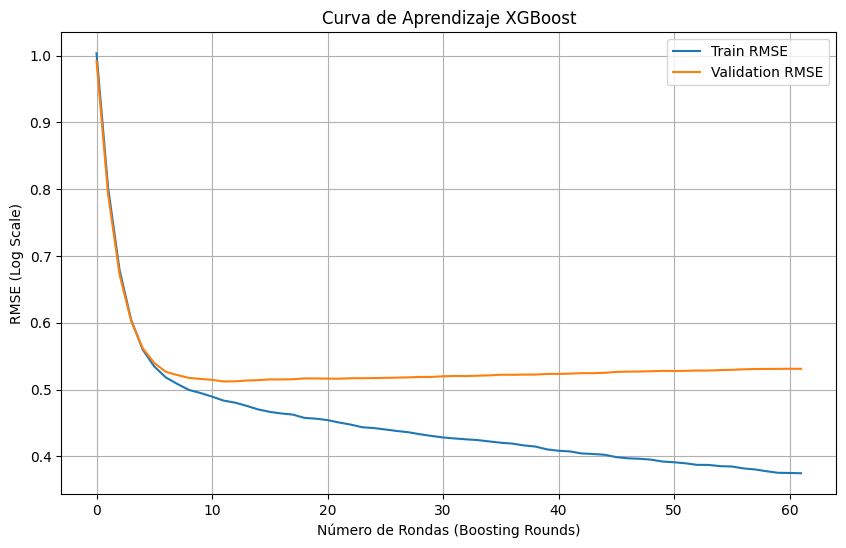

In [104]:
# Extraer los datos del diccionario
train_metric = resultado_evaluacion['train']['rmse']
val_metric = resultado_evaluacion['validation']['rmse']
epochs = len(train_metric)
x_axis = range(0, epochs)

# Graficar
plt.figure(figsize=(10, 6))
plt.plot(x_axis, train_metric, label='Train RMSE')
plt.plot(x_axis, val_metric, label='Validation RMSE')

plt.title('Curva de Aprendizaje XGBoost')
plt.xlabel('Número de Rondas (Boosting Rounds)')
plt.ylabel('RMSE (Log Scale)')
plt.legend()
plt.grid(True)
plt.show()

In [101]:
print("RMSE de validación mínimo:", np.min(resultado_evaluacion['validation']['rmse']))

RMSE de validación mínimo: 0.512162922756174


---

# MODELO 2

In [14]:
ev2.discount_percentage.value_counts()

discount_percentage
0.00    4953
0.10     161
0.20     140
0.17     119
0.13     117
        ... 
0.65       1
0.81       1
0.77       1
0.82       1
0.76       1
Name: count, Length: 72, dtype: int64

In [118]:
# Nuevos parámetros más "profesionales"
params_v2 = {
    "objective": "reg:squarederror",
    "eta": 0.05,             # <--- CLAVE: Mucho más bajo que el default (0.3)
    "max_depth": 6,          # Puedes probar a cambiarlo a 4 u 8 luego
    "subsample": 0.7,        # Usar solo el 70% de filas en cada árbol (evita overfitting)
    "colsample_bytree": 0.7, # Usar solo el 70% de columnas en cada árbol
    "eval_metric": "rmse"    # Para ver el rmse en el log
}

# Ejecutamos CV de nuevo
# Damos muchas rondas (5000) porque con eta bajo va a necesitar muchas más que 15
cv_results = xgb.cv(
    params_v2,
    dtrain_reg,
    num_boost_round=5000,    # Le damos margen de sobra
    nfold=5,
    early_stopping_rounds=50, # Más paciencia
    seed=42
)

best_rmse = cv_results['test-rmse-mean'].min()
optimum_rounds = cv_results['test-rmse-mean'].idxmin() + 1

print(f"Nuevo RMSE: {best_rmse}")
print(f"Nuevas rondas óptimas: {optimum_rounds}")

Nuevo RMSE: 0.5347579041559742
Nuevas rondas óptimas: 151


In [119]:
# 1. Los hiperparámetros de tu experimento (los que dieron 0.53)
params_final = {
    "objective": "reg:squarederror",
    "eta": 0.05,              # El learning rate bajo que usaste
    "max_depth": 6,           # Valor por defecto (o cámbialo si usaste otro en el CV)
    "subsample": 0.7,         # La regularización que añadimos
    "colsample_bytree": 0.7,  # La regularización que añadimos
    "eval_metric": "rmse"
}

# 2. Entrenamos el modelo FINAL con TODA la data
# Nota: Ya no usamos early_stopping ni evals, vamos directos a la meta (151).
model = xgb.train(
    params=params_final,
    dtrain=dtrain_reg,       # IMPORTANTE: Que esto contenga TODOS tus datos (Train + Test)
    num_boost_round=151      # El número exacto que nos dio el CV
)

print("¡Modelo definitivo entrenado y listo!")

# 3. (Opcional) Guardar el modelo para usarlo mañana
# model_final.save_model("mi_modelo_xgboost_v1.json")

¡Modelo definitivo entrenado y listo!


---

# MODELO 3

In [ ]:
dtrain_reg = xgb.DMatrix(X_train, y_train, enable_categorical=True)
dtest_reg = xgb.DMatrix(X_test, y_test, enable_categorical=True)

In [115]:
params = {
    'objective': 'reg:squarederror',  # o 'reg:absoluteerror' si hay outliers
    'eval_metric': ['rmse', 'mae'],
    'tree_method': 'hist',  # Más rápido
    'max_depth': 6,
    'learning_rate': 0.05,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'min_child_weight': 3,
    'gamma': 0,
    'reg_alpha': 0,  # L1
    'reg_lambda': 1,  # L2
    'random_state': 42
}

In [56]:
evals = [(dtrain_reg, 'train'), (dtest_reg, 'val')]
model = xgb.train(
    params,
    dtrain_reg,
    num_boost_round=3000,
    evals=evals,
    early_stopping_rounds=50,
    verbose_eval=100
)
best_iteration = model.best_iteration

[0]	train-rmse:1.26358	train-mae:1.03878	val-rmse:1.25178	val-mae:1.01934
[100]	train-rmse:0.47450	train-mae:0.37964	val-rmse:0.51064	val-mae:0.40954
[146]	train-rmse:0.45286	train-mae:0.36179	val-rmse:0.51039	val-mae:0.40953


In [116]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    'max_depth': [3, 5, 7, 9],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'min_child_weight': [1, 3, 5, 7],
    'gamma': [0, 0.1, 0.5, 1],
    'reg_alpha': [0, 0.1, 1, 10],
    'reg_lambda': [1, 5, 10, 50]
}

xgb_model = xgb.XGBRegressor(
    objective='reg:squarederror',
    n_estimators=best_iteration,
    tree_method='hist',
    enable_categorical=True
)

random_search = RandomizedSearchCV(
    xgb_model,
    param_distributions=param_dist,
    n_iter=50,
    scoring='neg_mean_squared_error',
    cv=5,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train, y_train)

Fitting 5 folds for each of 50 candidates, totalling 250 fits


c:\Users\USER\anaconda3\envs\TFM\Lib\site-packages\joblib\externals\loky\process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


RandomizedSearchCV(cv=5,
                   estimator=XGBRegressor(base_score=None, booster=None,
                                          callbacks=None,
                                          colsample_bylevel=None,
                                          colsample_bynode=None,
                                          colsample_bytree=None, device=None,
                                          early_stopping_rounds=None,
                                          enable_categorical=True,
                                          eval_metric=None, feature_types=None,
                                          feature_weights=None, gamma=None,
                                          grow_policy=None,
                                          importance_type=None,
                                          interaction_constraints...
                                          n_jobs=None, num_parallel_tree=None, ...),
                   n_iter=50, n_jobs=-1,
                   param_distributions={'colsample_bytree': [0.6, 0.8, 1.0],
                                        'gamma': [0, 0.1, 0.5, 1],
                                        'learning_rate': [0.01, 0.05, 0.1],
                                        'max_depth': [3, 5, 7, 9],
                                        'min_child_weight': [1, 3, 5, 7],
                                        'reg_alpha': [0, 0.1, 1, 10],
                                        'reg_lambda': [1, 5, 10, 50],
                                        'subsample': [0.6, 0.8, 1.0]},
                   random_state=42, scoring='neg_mean_squared_error',
                   verbose=1)

In [118]:
best_model = random_search.best_estimator_
print(f"Mejores parámetros: {random_search.best_params_}")

Mejores parámetros: {'subsample': 0.6, 'reg_lambda': 1, 'reg_alpha': 0, 'min_child_weight': 5, 'max_depth': 9, 'learning_rate': 0.05, 'gamma': 1, 'colsample_bytree': 0.8}


RMSE: 0.5121770057158961
MAE: 0.41085278015314713
R²: 0.8460040723372473


<Axes: title={'center': 'Feature importance'}, xlabel='Importance score', ylabel='Features'>

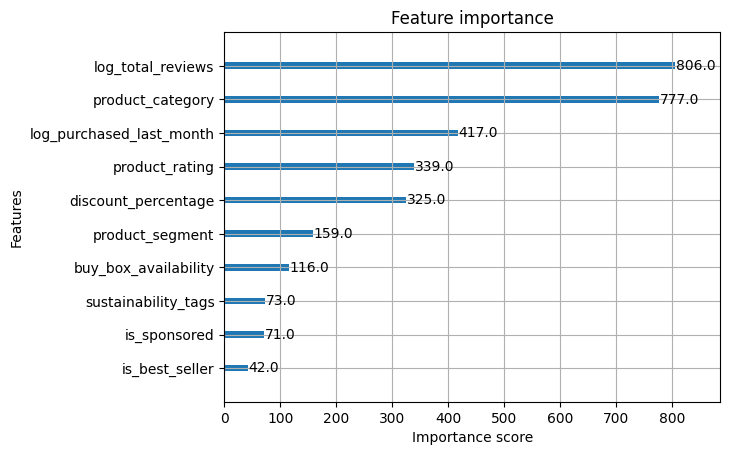

In [119]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

y_pred = best_model.predict(X_test)

print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred))}")
print(f"MAE: {mean_absolute_error(y_test, y_pred)}")
print(f"R²: {r2_score(y_test, y_pred)}")

# Analizar importancia de features
xgb.plot_importance(best_model, max_num_features=10)


=== MEJORES PARÁMETROS ===
subsample: 0.6
reg_lambda: 1
reg_alpha: 1
min_child_weight: 1
max_depth: 9
learning_rate: 0.1
gamma: 1
colsample_bytree: 1.0

Mejor score CV: 0.2836


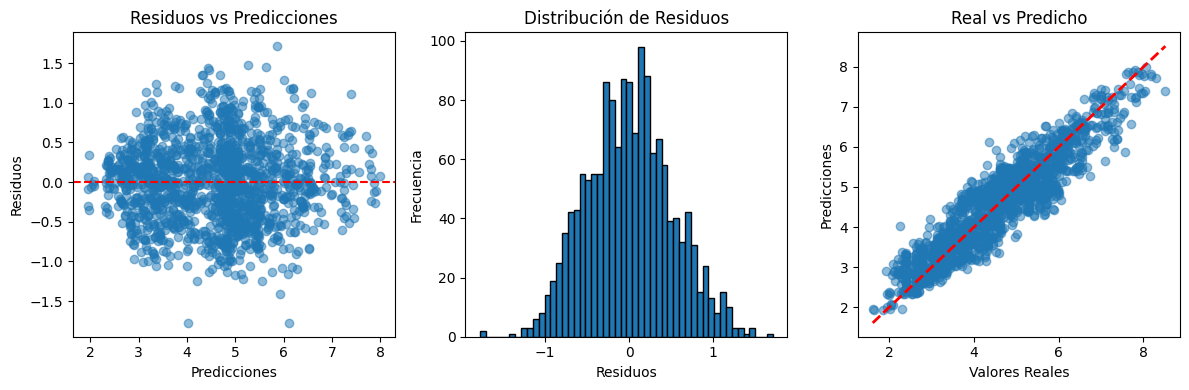

In [87]:
# Ver los mejores parámetros encontrados
print("\n=== MEJORES PARÁMETROS ===")
for param, value in random_search.best_params_.items():
    print(f"{param}: {value}")

# Ver el score de validación cruzada del mejor modelo
print(f"\nMejor score CV: {-random_search.best_score_:.4f}")

# Análisis de residuos
residuals = y_test - y_pred

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.scatter(y_pred, residuals, alpha=0.5)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Predicciones')
plt.ylabel('Residuos')
plt.title('Residuos vs Predicciones')

plt.subplot(1, 3, 2)
plt.hist(residuals, bins=50, edgecolor='black')
plt.xlabel('Residuos')
plt.ylabel('Frecuencia')
plt.title('Distribución de Residuos')

plt.subplot(1, 3, 3)
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Valores Reales')
plt.ylabel('Predicciones')
plt.title('Real vs Predicho')

plt.tight_layout()
plt.show()

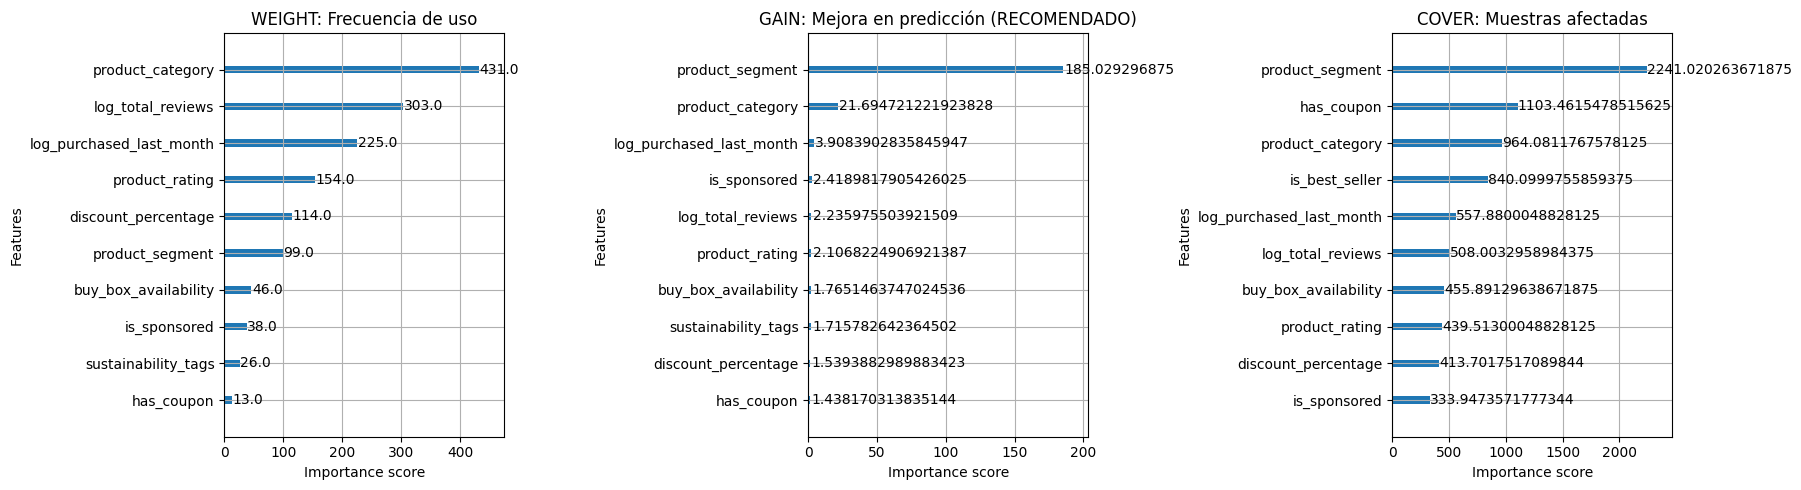

In [88]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

xgb.plot_importance(best_model, max_num_features=10, 
                    importance_type='weight', ax=axes[0])
axes[0].set_title('WEIGHT: Frecuencia de uso')

xgb.plot_importance(best_model, max_num_features=10, 
                    importance_type='gain', ax=axes[1])
axes[1].set_title('GAIN: Mejora en predicción (RECOMENDADO)')

xgb.plot_importance(best_model, max_num_features=10, 
                    importance_type='cover', ax=axes[2])
axes[2].set_title('COVER: Muestras afectadas')

plt.tight_layout()
plt.show()

# SENTENCE-BERT AL TITULO

In [98]:
ev2

,product_title,product_rating,is_best_seller,is_sponsored,buy_box_availability,sustainability_tags,has_coupon,discount_percentage,product_category,product_segment,log_original_price,log_purchased_last_month,log_total_reviews
0,OWC 2.0TB Aura Pro X2 (GEN 4) SSD Complete Upg...,4.4,No Badge,Sponsored,1,0,0,0.00,PC Components,Media,5.484755,0.000000,5.883322
1,OWC 250GB Aura Pro 6G Flash SSD Upgrade for 20...,4.6,No Badge,Sponsored,1,0,0,0.00,Storage & Memory Cards,Media,3.783962,0.000000,5.624018
2,HP 67XL Black High-yield Ink Cartridge | Works...,4.6,Best Seller,Organic,0,1,0,0.00,"Office Supplies, Ink & Toner",Media,3.607941,10.819798,11.523598
3,HP 67 Black/Tri-color Ink Cartridges for HP Pr...,4.6,No Badge,Organic,0,0,0,0.00,"Office Supplies, Ink & Toner",Media,3.804215,10.819798,10.986868
4,"Sony ZX Series Wired On-Ear Headphones, Black ...",4.5,Best Seller,Organic,0,0,0,0.00,"Audio, Sound & Recording Gear",Baja,2.355178,9.210440,11.598433
...,...,...,...,...,...,...,...,...,...,...,...,...,...
7712,"VIVO Universal Wooden Laptop Treadmill Desk, A...",4.0,No Badge,Organic,1,0,0,0.00,Computer Peripherals,Media,4.394326,5.303305,7.140453
7713,Neewer NP-FZ100 2400mAh Battery for Sony A7R V...,4.6,No Badge,Organic,0,0,1,0.26,"Chargers, Adapters & Cables",Media,3.555062,5.707110,6.734592
7714,Monoprice XLR Male to 1/4-Inch TRS Male Cable ...,4.7,No Badge,Organic,1,0,0,0.35,"Audio, Sound & Recording Gear",Baja,2.832036,6.216606,8.868273
7715,Dell Desktop Computer Package Compatible with ...,3.9,No Badge,Organic,0,0,0,0.00,PC Components,Media,4.820282,4.615121,6.683361


In [111]:
from sentence_transformers import SentenceTransformer
from sklearn.decomposition import PCA
# Guardar los títulos también separados
titles_train = ev2.loc[X_train.index, 'product_title']
titles_test = ev2.loc[X_test.index, 'product_title']

# 2. APLICAR SBERT SOLO EN TRAIN
print("Generando embeddings para TRAIN...")
model = SentenceTransformer('all-mpnet-base-v2')

embeddings_train = model.encode(
    titles_train.tolist(),
    batch_size=64,
    show_progress_bar=True
)

# 3. AJUSTAR PCA SOLO EN TRAIN
n_components = min(30, len(X_train) - 1, embeddings_train.shape[1])
pca = PCA(n_components=n_components, random_state=42)
embeddings_train_reduced = pca.fit_transform(embeddings_train)  # fit_transform en TRAIN

# 4. APLICAR PCA EN TEST (solo transform, NO fit)
print("Generando embeddings para TEST...")
embeddings_test = model.encode(
    titles_test.tolist(),
    batch_size=64,
    show_progress_bar=True
)
embeddings_test_reduced = pca.transform(embeddings_test)  # solo transform en TEST

# 5. CREAR DATAFRAMES
train_sbert_df = pd.DataFrame(
    embeddings_train_reduced,
    columns=[f'title_sbert_{i}' for i in range(n_components)],
    index=X_train.index
)

test_sbert_df = pd.DataFrame(
    embeddings_test_reduced,
    columns=[f'title_sbert_{i}' for i in range(n_components)],
    index=X_test.index
)

# 6. COMBINAR CON FEATURES ORIGINALES
X_train_final = pd.concat([X_train, train_sbert_df], axis=1)
X_test_final = pd.concat([X_test, test_sbert_df], axis=1)

Generando embeddings para TRAIN...


c:\Users\USER\anaconda3\envs\TFM\Lib\site-packages\huggingface_hub\file_download.py:942: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


Batches:   0%|          | 0/97 [00:00<?, ?it/s]

Generando embeddings para TEST...


Batches:   0%|          | 0/25 [00:00<?, ?it/s]

In [101]:
X_with_sbert[X_with_sbert['product_category'] == 'Laptops']

,product_title,product_rating,is_best_seller,is_sponsored,buy_box_availability,sustainability_tags,has_coupon,discount_percentage,product_category,product_segment,...,title_sbert_20,title_sbert_21,title_sbert_22,title_sbert_23,title_sbert_24,title_sbert_25,title_sbert_26,title_sbert_27,title_sbert_28,title_sbert_29
21,Apple 2025 MacBook Air 13-inch Laptop with M4 ...,4.8,Best Seller,Organic,0,1,0,0.00,Laptops,Media,...,-0.083993,-0.071173,-0.048956,0.096489,0.091270,-0.003665,-0.089994,-0.052365,-0.002196,0.017308
61,"Apple 2024 MacBook Pro Laptop with M4 Pro, 12-...",4.8,No Badge,Organic,0,1,0,0.00,Laptops,Alta/Premium,...,-0.090246,0.008317,-0.002180,0.075420,0.051475,0.017415,-0.078718,-0.049850,0.071206,-0.139491
66,"HP 14 Laptop, Intel Celeron N4020, 4 GB RAM, 6...",4.1,No Badge,Organic,1,0,0,0.25,Laptops,Media,...,0.010595,-0.073628,0.065118,0.034274,-0.106819,0.016217,-0.068657,-0.020729,-0.024229,-0.011076
109,Apple 2025 MacBook Air 15-inch Laptop with M4 ...,4.8,No Badge,Organic,0,1,0,0.00,Laptops,Media,...,-0.064290,-0.072783,-0.028841,0.112345,0.113618,-0.015756,-0.102733,-0.078890,-0.008755,0.004218
143,acer 311 Chromebook 2025 Flagship Slim Light L...,4.2,No Badge,Sponsored,1,0,1,0.00,Laptops,Media,...,-0.048277,-0.083030,-0.058957,0.028492,-0.043457,0.050422,0.025192,0.014217,-0.042896,-0.009294
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7661,Apple 2022 MacBook Air Laptop with M2 chip (13...,4.3,No Badge,Sponsored,0,0,0,0.29,Laptops,Media,...,0.001939,-0.058479,0.036556,0.098384,-0.016858,0.014411,0.002410,-0.014878,-0.032118,0.076567
7671,"Lenovo Legion Pro 7i Gen 10 16"" Gaming Laptop ...",5.0,No Badge,Organic,0,0,0,0.00,Laptops,Alta/Premium,...,0.105397,-0.065160,-0.051685,-0.016409,-0.049317,0.049241,0.015703,-0.064146,-0.054470,-0.019249
7680,"Microsoft Surface Laptop Studio 2 14.4"" Touchs...",5.0,No Badge,Organic,0,0,0,0.00,Laptops,Alta/Premium,...,0.001642,0.026868,-0.068521,-0.046039,-0.036200,0.017163,0.019051,-0.030425,0.060665,0.027950
7682,acer 2-Pack Laptop Privacy Screen - for Laptop...,0.0,No Badge,Sponsored,1,0,1,0.17,Laptops,Baja,...,-0.029632,-0.023311,-0.047475,0.066863,-0.029841,-0.132632,0.078275,-0.082195,-0.135133,0.115473


---

# EVALUACIÓN 

In [ ]:
from sklearn.metrics import median_absolute_error
from sklearn.metrics import mean_squared_error

preds = model.predict(dtest_reg)
y_test_euro = np.expm1(y_test)
y_pred_euro = np.expm1(y_pred)

mae = mean_absolute_error(y_test_euro, y_pred_euro)
rmse = np.sqrt(mean_squared_error(y_test_euro, y_pred_euro))
medae = median_absolute_error(y_test_euro, y_pred_euro)
mape = np.mean(np.abs((y_test_euro - y_pred_euro) / y_test_euro)) * 100


df_residuos = pd.DataFrame({
    'Real': y_test_euro,
    'Pred': y_pred_euro,
    'Error_Abs': np.abs(y_test_euro - y_pred_euro)
})


df_residuos['ErrorRelativo%'] = (df_residuos['Error_Abs'] / df_residuos['Real']) * 100

for col in [c for c in X_test.columns if 'segment' in c]:
    mask = X_test[col] == 1
    error_rel_seg = df_residuos.loc[mask, 'ErrorRelativo%'].mean()
    mae_seg = df_residuos.loc[mask, 'Error_Abs'].mean()
    print(f"Segmento {col}:")
    print(f"   - Error en Euros (MAE): {mae_seg:.2f} €")
    print(f"   - Error en % (MAPE):    {error_rel_seg:.2f} %")
    print("-" * 20)


print("📊 MÉTRICAS DE RENDIMIENTO (EUROS)")
print(f"MAE (Error Medio):      {mae:.2f} €")
print(f"MedAE (Error Típico):   {medae:.2f} €")
print(f"RMSE (Error Penalizado): {rmse:.2f} €")
print(f"MAPE (Error Porcentual): {mape:.2f} %")
print(f"R2 Score (Calidad):      {r2_score(y_test_euro, y_pred_euro):.4f}")
# print(f"R2 CV (Estabilidad):     {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")
print("="*40)
print("hola")
print("hola")


Segmento product_segment:
   - Error en Euros (MAE): nan €
   - Error en % (MAPE):    nan %
--------------------
📊 MÉTRICAS DE RENDIMIENTO (EUROS)
MAE (Error Medio):      87.66 €
MedAE (Error Típico):   30.53 €
RMSE (Error Penalizado): 209.15 €
MAPE (Error Porcentual): 45.19 %
R2 Score (Calidad):      0.7648
hola
hola


--- Métricas de Evaluación en Test Set ---
MSE:  43743.6024
RMSE: 209.1497
MAE:  87.6615
R²:   0.7648


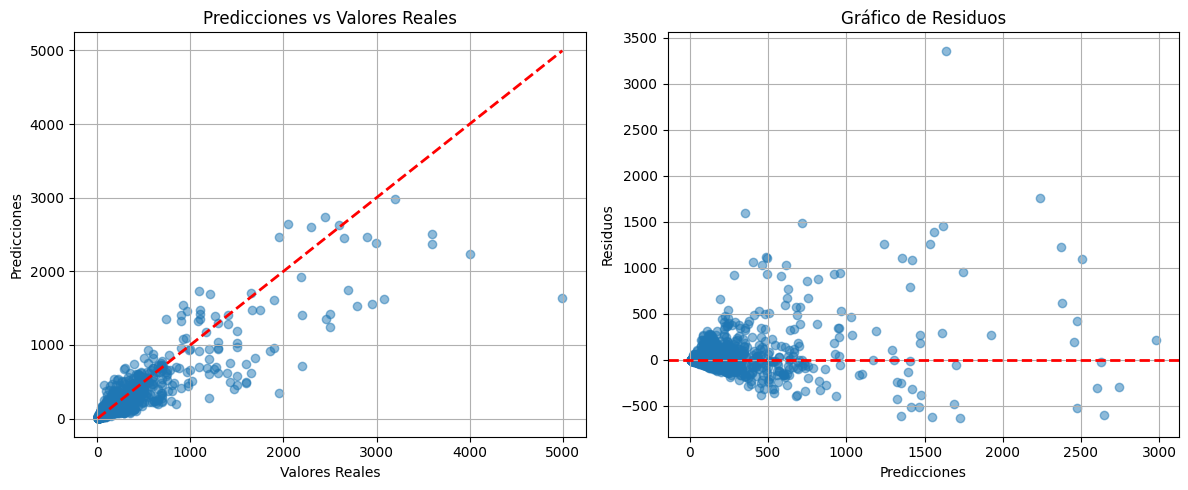

In [ ]:
# Visualizar predicciones vs valores reales
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(y_test_euro, y_pred_euro, alpha=0.5)
plt.plot([y_test_euro.min(), y_test_euro.max()], [y_test_euro.min(), y_test_euro.max()], 'r--', lw=2)
plt.xlabel('Valores Reales')
plt.ylabel('Predicciones')
plt.title('Predicciones vs Valores Reales')
plt.grid(True)

plt.subplot(1, 2, 2)
residuals = y_test_euro - y_pred_euro
plt.scatter(y_pred_euro, residuals, alpha=0.5)
plt.axhline(y=0, color='r', linestyle='--', lw=2)
plt.xlabel('Predicciones')
plt.ylabel('Residuos')
plt.title('Gráfico de Residuos')
plt.grid(True)

# --- 4. GRÁFICO DE DIAGNÓSTICO: REAL VS PREDICHO ---
plt.figure(figsize=(8, 6))
plt.scatter(y_test_euro, y_pred_euro, alpha=0.3, color='darkorange')
plt.plot([y_test_euro.min(), y_test_euro.max()], [y_test_euro.min(), y_test_euro.max()], 'k--', lw=2)
plt.xlabel("Precio Real (€)")
plt.ylabel("Predicción del Modelo (€)")
plt.title("Diagnóstico: ¿Dónde falla nuestro modelo?")

residuos = y_test_euro - y_pred_euro

plt.figure(figsize=(10, 6))
plt.scatter(y_test_euro, residuos, alpha=0.3, color='purple')
plt.axhline(y=0, color='red', linestyle='--')
plt.title("Análisis de Residuos (Error vs Precio Real)")
plt.xlabel("Precio Real (€)")
plt.ylabel("Error (Real - Predicho)")
plt.grid(True, alpha=0.3)

# Veamos el error por tramos de precio
print("Error medio en productos de menos de 50€:")
mask = y_test_euro < 50
if mask.any():
    print(f"{mean_absolute_error(y_test_euro[mask], y_pred_euro[mask]):.2f} €")

print("\nError medio en productos de más de 500€:")
mask = y_test_euro > 500
if mask.any():
    print(f"{mean_absolute_error(y_test_euro[mask], y_pred_euro[mask]):.2f} €")

plt.tight_layout()
plt.show()

# HASTA AQUÍ
ABAJO OTROS MODELOS DE XGBOOST

--- 

In [49]:
# --- PASO 2: Configuración del Modelo XGBoost ---
# Usamos parámetros sólidos para empezar. 
# 'n_estimators': número de árboles (iteraciones)
# 'max_depth': profundidad del árbol (controla la complejidad)
# 'learning_rate': velocidad de aprendizaje (menor es más preciso pero más lento)
xgb_model = xgb.XGBRegressor(
    objective='reg:squarederror',
    n_estimators=500,     
    learning_rate=0.05,    
    max_depth=6,         
    subsample=0.8,        # Usa el 80% de los datos por árbol para evitar overfitting
    colsample_bytree=0.8, # Usa el 80% de las columnas por árbol
    random_state=42,
    n_jobs=-1       
)

In [44]:
# --- PASO 3: Entrenamiento con Early Stopping ---
print("Iniciando entrenamiento inteligente...")

xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_test, y_test)], 
    verbose=False 
)

print(f"Mejor iteración: {xgb_model.best_iteration}")
print(f"Mejor score (RMSE): {xgb_model.best_score}")

Iniciando entrenamiento inteligente...
Mejor iteración: 149
Mejor score (RMSE): 0.8664917426649147


--- Métricas de Evaluación en Test Set ---
MSE:  119628.4748
RMSE: 345.8735
MAE:  141.8462
R²:   0.3568


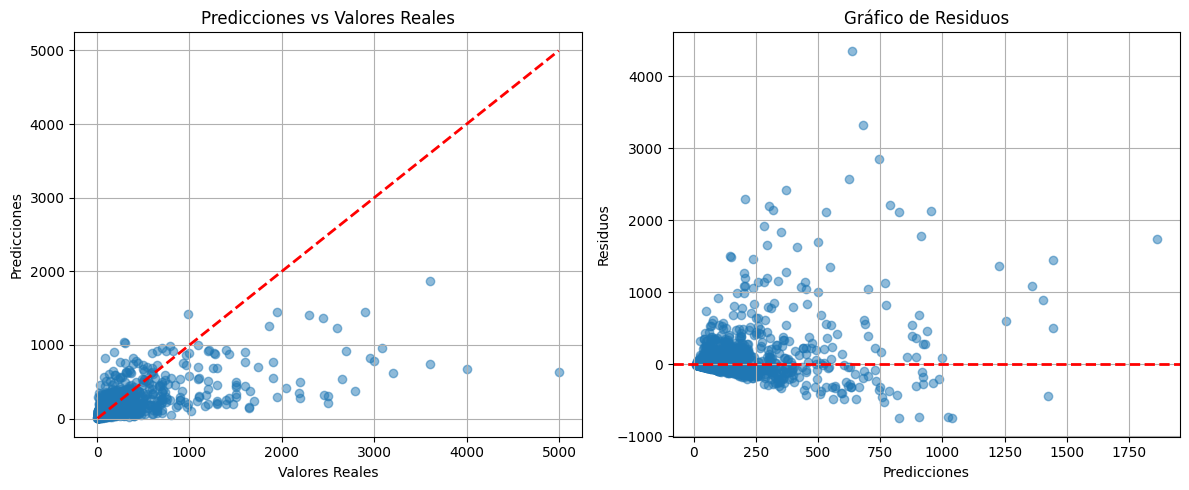

In [45]:
# 4 Evaluación
# Make predictions on test set
y_pred_log = xgb_model.predict(X_test)

# Invertimos el logaritmo para hablar en dinero (usando la fórmula de tu equipo)
y_test_euro = np.expm1(y_test)
y_pred_euro = np.expm1(y_pred_log)

# Calculate evaluation metrics
mse = mean_squared_error(y_test_euro, y_pred_euro)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test_euro, y_pred_euro)
r2 = r2_score(y_test_euro, y_pred_euro)

print("--- Métricas de Evaluación en Test Set ---")
print(f"MSE:  {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAE:  {mae:.4f}")
print(f"R²:   {r2:.4f}")

# Visualizar predicciones vs valores reales
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(y_test_euro, y_pred_euro, alpha=0.5)
plt.plot([y_test_euro.min(), y_test_euro.max()], [y_test_euro.min(), y_test_euro.max()], 'r--', lw=2)
plt.xlabel('Valores Reales')
plt.ylabel('Predicciones')
plt.title('Predicciones vs Valores Reales')
plt.grid(True)

plt.subplot(1, 2, 2)
residuals = y_test_euro - y_pred_euro
plt.scatter(y_pred_euro, residuals, alpha=0.5)
plt.axhline(y=0, color='r', linestyle='--', lw=2)
plt.xlabel('Predicciones')
plt.ylabel('Residuos')
plt.title('Gráfico de Residuos')
plt.grid(True)

plt.tight_layout()
plt.show()

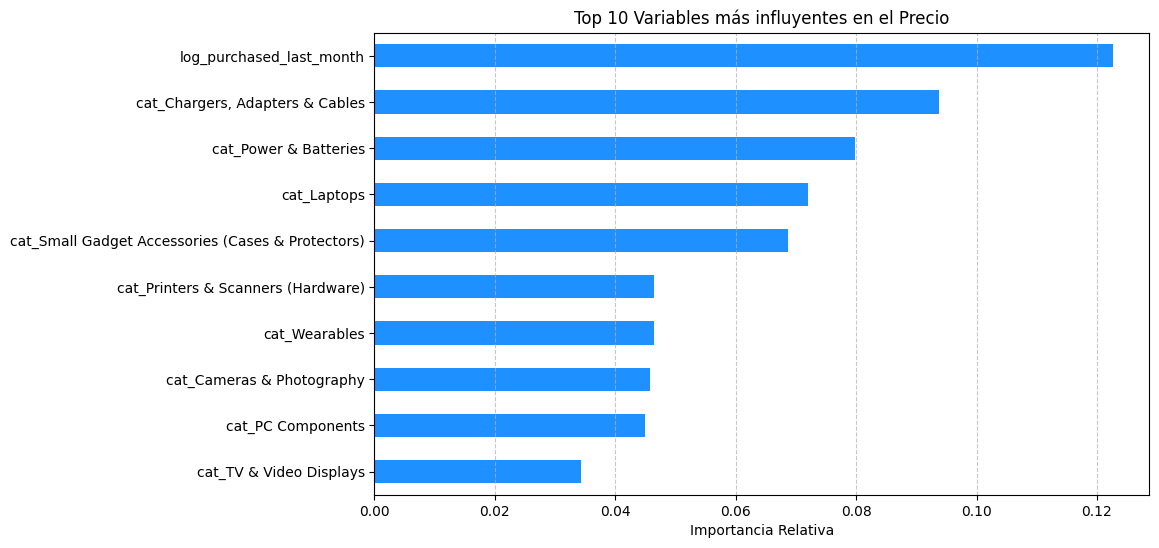

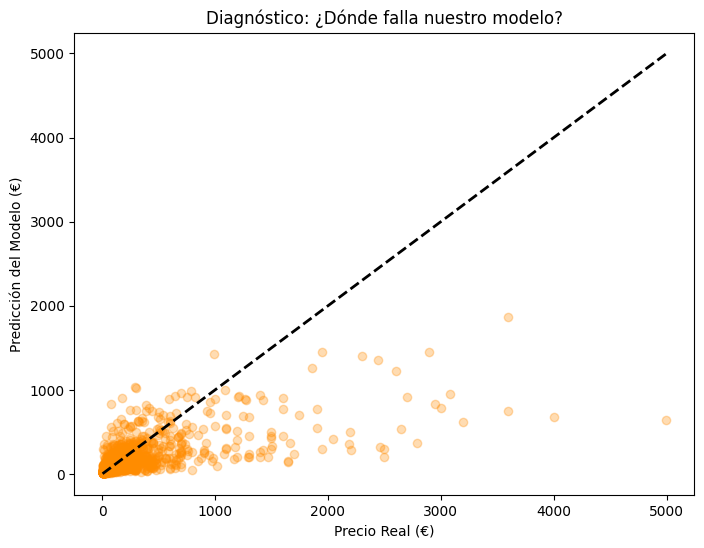

In [28]:
# --- 3. VISUALIZACIÓN DE IMPORTANCIA DE VARIABLES ---
# Esto responde a: ¿Qué es lo que más hace subir el precio en Amazon?
plt.figure(figsize=(10, 6))
importances = pd.Series(xgb_model.feature_importances_, index=X.columns)
importances.nlargest(10).sort_values(ascending=True).plot(kind='barh', color='dodgerblue')
plt.title("Top 10 Variables más influyentes en el Precio")
plt.xlabel("Importancia Relativa")
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

# --- 4. GRÁFICO DE DIAGNÓSTICO: REAL VS PREDICHO ---
plt.figure(figsize=(8, 6))
plt.scatter(y_test_euro, y_pred_euro, alpha=0.3, color='darkorange')
plt.plot([y_test_euro.min(), y_test_euro.max()], [y_test_euro.min(), y_test_euro.max()], 'k--', lw=2)
plt.xlabel("Precio Real (€)")
plt.ylabel("Predicción del Modelo (€)")
plt.title("Diagnóstico: ¿Dónde falla nuestro modelo?")
plt.show()

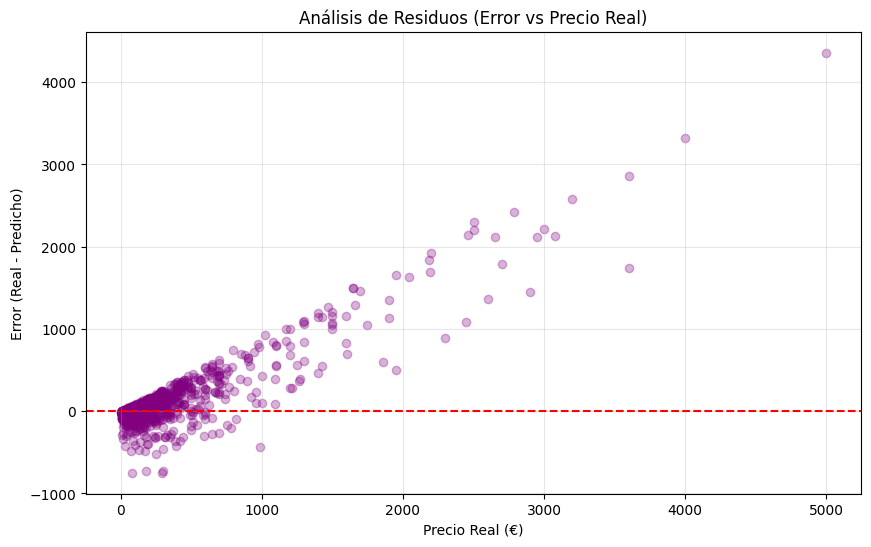

Error medio en productos de menos de 50€:
32.63 €

Error medio en productos de más de 500€:
744.13 €


In [ ]:
import matplotlib.pyplot as plt

# Creamos una columna de error (Residuos)2
residuos = y_test_euro - y_pred_euro

plt.figure(figsize=(10, 6))
plt.scatter(y_test_euro, residuos, alpha=0.3, color='purple')
plt.axhline(y=0, color='red', linestyle='--')
plt.title("Análisis de Residuos (Error vs Precio Real)")
plt.xlabel("Precio Real (€)")
plt.ylabel("Error (Real - Predicho)")
plt.grid(True, alpha=0.3)
plt.show()

# Veamos el error por tramos de precio
print("Error medio en productos de menos de 50€:")
mask = y_test_euro < 50
if mask.any():
    print(f"{mean_absolute_error(y_test_euro[mask], y_pred_euro[mask]):.2f} €")

print("\nError medio en productos de más de 500€:")
mask = y_test_euro > 500
if mask.any():
    print(f"{mean_absolute_error(y_test_euro[mask], y_pred_euro[mask]):.2f} €")

In [50]:
from sklearn.model_selection import GridSearchCV

# --- PASO 5: Ajuste de Hiperparámetros con GridSearchCV ---

# Definir la cuadrícula de parámetros a probar
param_grid = {
    'max_depth': [4, 6, 8],
    'learning_rate': [0.01, 0.05, 0.1],
    'n_estimators': [300, 500, 700],
    'subsample': [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.9]
}

# Crear GridSearchCV
grid_search = GridSearchCV(
    estimator=xgb.XGBRegressor(
        objective='reg:squarederror',
        random_state=42,
        n_jobs=-1,
    ),
    param_grid=param_grid,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    verbose=1
)

# Entrenar con GridSearchCV
print("Iniciando búsqueda de hiperparámetros...")
grid_search.fit(X_train, y_train)

# Resultados
print(f"\nMejores parámetros: {grid_search.best_params_}")
print(f"Mejor score (CV): {-grid_search.best_score_:.4f}")

# Usar el mejor modelo
best_xgb_model = grid_search.best_estimator_
y_pred_best = best_xgb_model.predict(X_test)
y_pred_euro_best = np.expm1(y_pred_best)

# Evaluar el mejor modelo
mse_best = mean_squared_error(y_test_euro, y_pred_euro_best)
rmse_best = np.sqrt(mse_best)
mae_best = mean_absolute_error(y_test_euro, y_pred_euro_best)
r2_best = r2_score(y_test_euro, y_pred_euro_best)

print("\n--- Métricas del Mejor Modelo ---")
print(f"RMSE: {rmse_best:.4f}")
print(f"MAE:  {mae_best:.4f}")
print(f"R²:   {r2_best:.4f}")

Iniciando búsqueda de hiperparámetros...
Fitting 5 folds for each of 243 candidates, totalling 1215 fits

Mejores parámetros: {'colsample_bytree': 0.7, 'learning_rate': 0.01, 'max_depth': 8, 'n_estimators': 700, 'subsample': 0.8}
Mejor score (CV): 0.7757

--- Métricas del Mejor Modelo ---
RMSE: 342.3143
MAE:  140.7848
R²:   0.3700
